In [34]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

In [25]:
# Loading the data
df_clean = pd.read_csv("C:/Users/user/Zambia_Economic_Analysis/data/cleaned datasets/df_clean.csv")
df_forecast = pd.read_csv("C:/Users/user/Zambia_Economic_Analysis/data/cleaned datasets/df_forecast.csv")
df_debt = pd.read_csv("C:/Users/user/Zambia_Economic_Analysis/data/cleaned datasets/debt_data.csv")

In [26]:
# Checking the first few rows of the cleaned dataset
df_clean.head()

,Year,GDP_Growth,Inflation,Debt_GDP,FDI_GDP,Population,Exchange_Rate,Copper_Price,Population_growth,GDP_Lag1,Inflation_Lag1
0,1964-01-01,12.214048,NaN,NaN,NaN,3577017,0.714286,0.403233,NaN,NaN,NaN
1,1965-01-01,16.647456,NaN,NaN,NaN,3692086,0.714286,0.489251,3.216898,12.214048,NaN
2,1966-01-01,-5.570310,NaN,NaN,NaN,3812003,0.714286,0.633821,3.247947,16.647456,NaN
3,1967-01-01,7.919697,NaN,NaN,NaN,3936343,0.714286,0.491840,3.261802,-5.570310,NaN
4,1968-01-01,1.248330,NaN,NaN,NaN,4065593,0.714286,0.507980,3.283505,7.919697,NaN


In [27]:
# Checking the first few rows of the forecast dataset
df_forecast.head()

,Year,GDP_Growth,Inflation,Debt_GDP,FDI_GDP,Population,Exchange_Rate,Copper_Price,Population_growth,GDP_Lag1,Inflation_Lag1
0,1990-01-01,-0.481072,107.023809,244.380536,6.164126,7786169,0.030289,1.232874,2.595169,-1.023502,123.404255
1,1991-01-01,-0.036133,97.642323,277.530308,1.015753,7981650,0.064640,1.089791,2.510619,-0.481072,107.023809
2,1992-01-01,-1.730922,165.706527,164.700754,1.413845,8176680,0.172214,1.071956,2.443480,-0.036133,97.642323
3,1993-01-01,6.797274,183.312041,161.786077,9.604383,8373921,0.452763,0.914470,2.412238,-1.730922,165.706527
4,1994-01-01,-8.625442,54.601322,149.209890,1.093851,8576269,0.669371,1.114643,2.416407,6.797274,183.312041


In [28]:
#Checking the first few rows of the debt dataset
df_debt.head()

,Year,GDP_Growth,Inflation,Debt_GDP,FDI_GDP,Population,Exchange_Rate,Copper_Price,Population_growth,GDP_Lag1,Inflation_Lag1
0,1990-01-01,-0.481072,107.023809,244.380536,6.164126,7786169,0.030289,1.232874,2.595169,-1.023502,123.404255
1,1991-01-01,-0.036133,97.642323,277.530308,1.015753,7981650,0.064640,1.089791,2.510619,-0.481072,107.023809
2,1992-01-01,-1.730922,165.706527,164.700754,1.413845,8176680,0.172214,1.071956,2.443480,-0.036133,97.642323
3,1993-01-01,6.797274,183.312041,161.786077,9.604383,8373921,0.452763,0.914470,2.412238,-1.730922,165.706527
4,1994-01-01,-8.625442,54.601322,149.209890,1.093851,8576269,0.669371,1.114643,2.416407,6.797274,183.312041


In [29]:
# Comverting 'Year' column to datetime format for easier handling
df_clean['Year'] = pd.to_datetime(df_clean['Year'])
df_forecast['Year'] =pd.to_datetime(df_forecast['Year'])
df_debt['Year'] =pd.to_datetime(df_debt['Year'])


# Checking for the first few rows of the cleaned dataset after converting 'Year' to datetime
df_clean.head()

,Year,GDP_Growth,Inflation,Debt_GDP,FDI_GDP,Population,Exchange_Rate,Copper_Price,Population_growth,GDP_Lag1,Inflation_Lag1
0,1964-01-01,12.214048,NaN,NaN,NaN,3577017,0.714286,0.403233,NaN,NaN,NaN
1,1965-01-01,16.647456,NaN,NaN,NaN,3692086,0.714286,0.489251,3.216898,12.214048,NaN
2,1966-01-01,-5.570310,NaN,NaN,NaN,3812003,0.714286,0.633821,3.247947,16.647456,NaN
3,1967-01-01,7.919697,NaN,NaN,NaN,3936343,0.714286,0.491840,3.261802,-5.570310,NaN
4,1968-01-01,1.248330,NaN,NaN,NaN,4065593,0.714286,0.507980,3.283505,7.919697,NaN


In [30]:
# Dataset overview
# Variable types, non-null counts, and memory usage
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Year               61 non-null     datetime64[us]
 1   GDP_Growth         61 non-null     float64       
 2   Inflation          39 non-null     float64       
 3   Debt_GDP           21 non-null     float64       
 4   FDI_GDP            55 non-null     float64       
 5   Population         61 non-null     int64         
 6   Exchange_Rate      61 non-null     float64       
 7   Copper_Price       61 non-null     float64       
 8   Population_growth  60 non-null     float64       
 9   GDP_Lag1           60 non-null     float64       
 10  Inflation_Lag1     38 non-null     float64       
dtypes: datetime64[us](1), float64(9), int64(1)
memory usage: 5.4 KB


In [31]:
# Summary statistics for numerical columns
df_clean.describe()

,Year,GDP_Growth,Inflation,Debt_GDP,FDI_GDP,Population,Exchange_Rate,Copper_Price,Population_growth,GDP_Lag1,Inflation_Lag1
count,61,61.000000,39.000000,21.000000,55.000000,6.100000e+01,61.000000,61.000000,60.000000,60.000000,38.000000
mean,1993-12-31 20:51:08.852459,3.454570,35.236352,105.348764,3.481361,9.928663e+06,3.870916,1.581366,3.019932,3.448479,35.769266
min,1964-01-01 00:00:00,-8.625442,6.429397,17.321511,-0.958054,3.577017e+06,0.000643,0.403233,2.412238,-8.625442,6.429397
25%,1979-01-01 00:00:00,-0.086040,10.383971,46.432894,1.362533,5.631728e+06,0.008266,0.668158,2.846143,-0.148738,10.247282
50%,1994-01-01 00:00:00,3.897323,18.324440,71.411176,2.810624,8.576269e+06,0.714286,1.008752,3.048989,3.965908,19.859111
75%,2009-01-01 00:00:00,6.280749,39.001343,161.232158,5.033818,1.349039e+07,4.797500,2.721849,3.230115,6.317601,41.037220
max,2024-01-01 00:00:00,16.647456,183.312041,277.530308,9.604383,2.131496e+07,26.166419,4.244540,3.631006,16.647456,183.312041
std,NaN,4.545495,42.950308,76.522391,2.664945,5.129237e+06,5.893351,1.199437,0.304500,4.583603,43.395982


In [32]:
# checking for missing values in the cleaned dataset
df_clean.isna().sum()

Year                  0
GDP_Growth            0
Inflation            22
Debt_GDP             40
FDI_GDP               6
Population            0
Exchange_Rate         0
Copper_Price          0
Population_growth     1
GDP_Lag1              1
Inflation_Lag1       23
dtype: int64

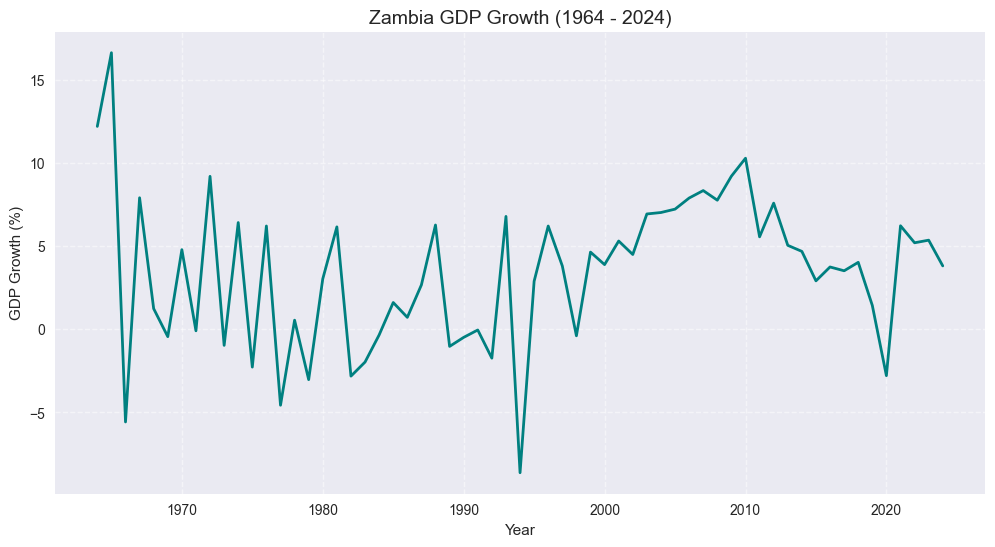

In [ ]:
# GDP Growth Trend (1964 - 2024)

plt.figure(figsize=(12, 6))
plt.plot(df_clean['Year'], df_clean['GDP_Growth'], linewidth=2, color='teal')
plt.title("Zambia GDP Growth (1964 - 2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 📉 GDP Growth Trend (1964–2024)

Zambia’s GDP growth shows a pattern of **high volatility**, reflecting the country’s exposure to external shocks, commodity cycles, and structural economic challenges. Several key periods stand out:

- **1960s–early 1970s:** Strong and stable growth supported by high copper prices and post‑independence investment.
- **Mid‑1970s–1990s:** A prolonged decline following the 1974 copper price crash, rising debt, and macroeconomic instability.
- **1998–2000:** Severe contractions linked to droughts, low copper prices, and structural adjustment pressures.
- **2004–2011:** A period of sustained growth driven by the global copper boom, debt relief (HIPC), and increased investment.
- **2015 downturn:** Growth slowed sharply due to falling copper prices, power shortages, and currency depreciation.
- **2020 recession:** COVID‑19, global supply disruptions, and domestic fiscal stress pushed GDP growth into negative territory.
- **2021–2024:** Gradual recovery, though growth remains sensitive to copper prices, weather patterns, and fiscal constraints.

Overall, Zambia’s GDP growth is heavily influenced by **commodity cycles**, **climate shocks**, and **macroeconomic stability**, making it one of the most volatile indicators in the dataset.


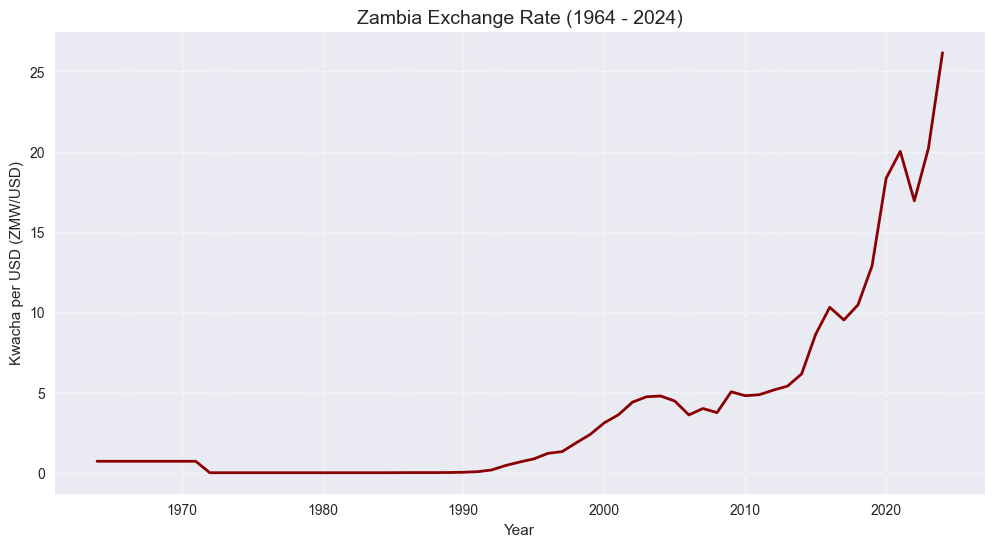

In [36]:
# Exchange Rate Trend (1964 - 2024)

plt.figure(figsize=(12, 6))
plt.plot(df_clean['Year'], df_clean['Exchange_Rate'], linewidth=2, color='darkred')
plt.title("Zambia Exchange Rate (1964 - 2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Kwacha per USD (ZMW/USD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 💱 Exchange Rate Trend (1964–2024)

Zambia’s exchange rate shows a long-term pattern of **persistent depreciation**, reflecting structural weaknesses in the economy and heavy dependence on external shocks. Several key phases stand out:

- **1964–1971:** Relative stability under a managed exchange rate regime.
- **1970s–1980s:** Gradual weakening as copper prices fell and external imbalances grew.
- **1990s:** Sharp depreciation during liberalization and the aftermath of hyperinflation.
- **2000–2010:** Periods of stabilization supported by rising copper prices and debt relief.
- **2015 crisis:** A major depreciation driven by falling copper prices, power shortages, and rising external debt.
- **2020–2021:** Another sharp weakening during the COVID‑19 shock and Zambia’s debt distress.
- **2022–2024:** Continued volatility reflecting global commodity cycles and domestic fiscal pressures.

The exchange rate is one of Zambia’s most sensitive macroeconomic indicators, reacting quickly to changes in copper prices, debt levels, inflation, and global financial conditions.


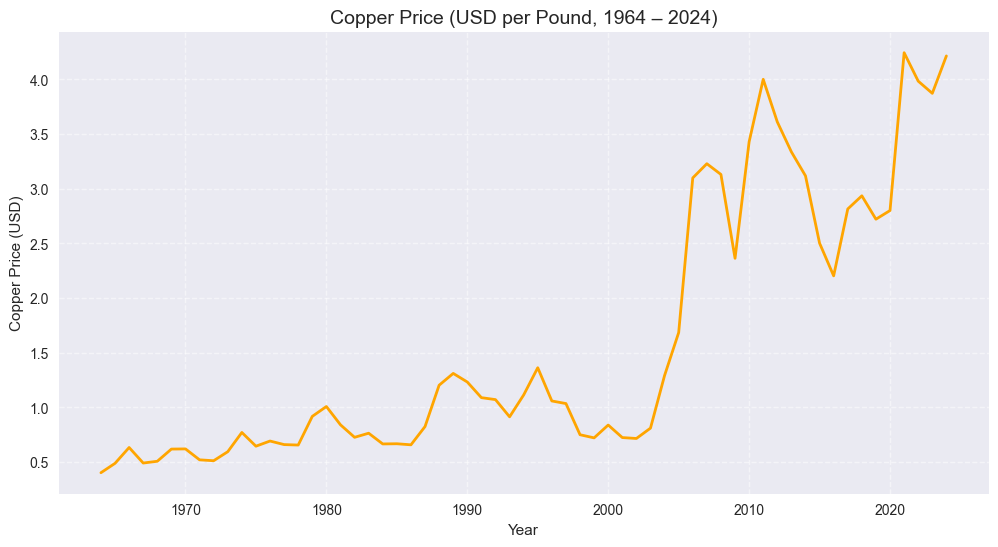

In [40]:
# Copper Price Trend (1964–2024)

plt.figure(figsize=(12, 6))
plt.plot(df_clean['Year'], df_clean['Copper_Price'], linewidth=2, color='orange')
plt.title("Copper Price (USD per Pound, 1964 – 2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Copper Price (USD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### 📈 Copper Price Trend (1964–2024)

Copper prices show several distinct cycles that align closely with Zambia’s economic performance:

- **1960s–early 1970s:** High copper prices supported strong economic growth.
- **1974 crash:** A sharp global copper price collapse triggered Zambia’s long-term economic decline.
- **1990s stagnation:** Prices remained low, contributing to weak growth and fiscal stress.
- **2004–2011 supercycle:** A major boom driven by Chinese demand led to strong GDP growth and increased investment.
- **2015 decline:** Falling copper prices contributed to FX depreciation and rising inflation.
- **2020–2022 recovery:** Prices rebounded due to global supply constraints and green energy demand.

Copper remains Zambia’s most important export commodity, and its price movements significantly influence fiscal stability, FX dynamics, and overall economic performance.


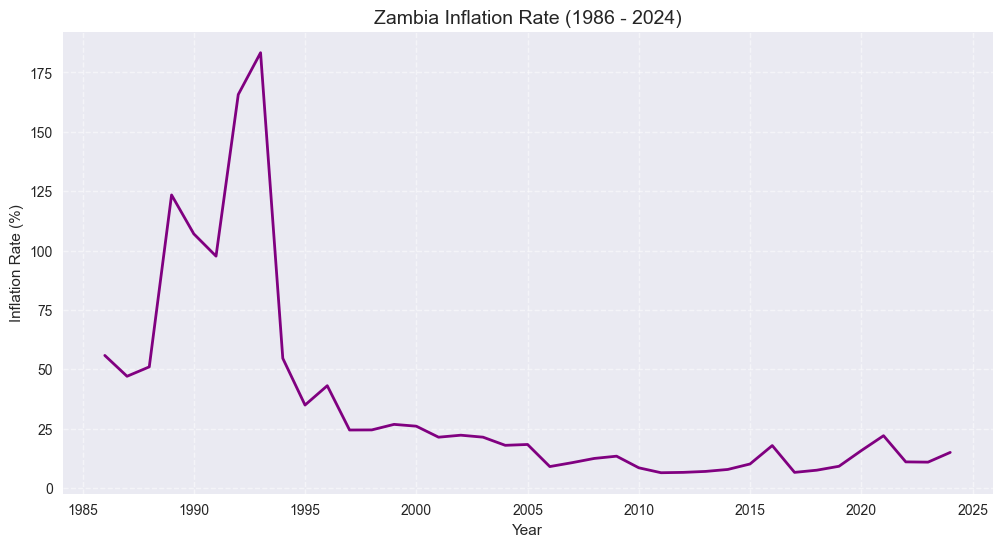

In [42]:
# Inflation trend (1986 - 2024)
# Filter years where inflation data is available
inflation_data = df_clean[df_clean['Inflation'].notna()]

plt.figure(figsize=(12, 6))
plt.plot(inflation_data['Year'], inflation_data['Inflation'], linewidth=2, color='purple')
plt.title("Zambia Inflation Rate (1986 - 2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.grid(True, linestyle='--', alpha=0.5)   
plt.show()

### 🔥 Inflation Rate Trend (1986–2024)

Zambia’s inflation history is marked by dramatic swings, reflecting deep structural challenges, policy transitions, and external shocks. Several distinct phases emerge:

- **Late 1980s–mid 1990s: Hyperinflation Era**  
  Inflation surged to extremely high levels due to fiscal imbalances, currency devaluations, and structural adjustment pressures. This period represents the most unstable inflation environment in Zambia’s post‑independence history.

- **2000–2010: Stabilization and Reform**  
  Inflation declined significantly following macroeconomic reforms, tighter monetary policy, and debt relief under the HIPC initiative. Improved copper prices also supported currency stability.

- **2015 Spike: FX and Power Crisis**  
  A sharp depreciation of the kwacha, combined with power shortages and rising import costs, pushed inflation upward again. This period marked a return to macroeconomic stress.

- **2020–2021: COVID‑19 Shock**  
  Global supply disruptions, reduced export earnings, and domestic fiscal pressures triggered another inflation surge.

- **2022–2024: Gradual Moderation**  
  Inflation began to ease as global conditions stabilized, though it remains sensitive to exchange rate movements, fuel prices, and weather‑related food supply shocks.

Overall, Zambia’s inflation trend highlights the economy’s vulnerability to **exchange rate depreciation**, **import dependence**, and **external shocks**, making price stability a persistent policy challenge.


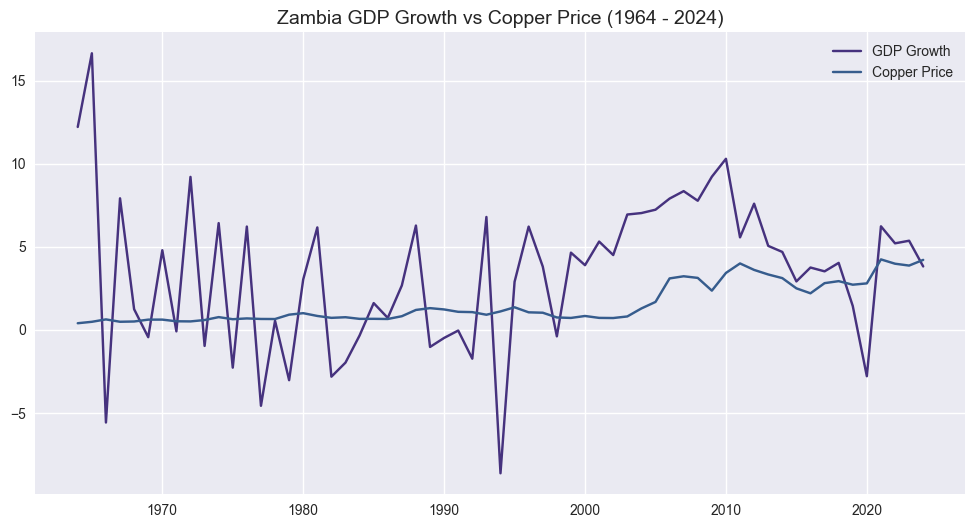

In [43]:
# An Overlay comparing GDP vs Copper Price (1964 - 2024)

plt.figure(figsize=(12, 6))
plt.plot(df_clean['Year'], df_clean['GDP_Growth'], label='GDP Growth')
plt.plot(df_clean['Year'], df_clean['Copper_Price'], label='Copper Price')
plt.legend()
plt.title("Zambia GDP Growth vs Copper Price (1964 - 2024)", fontsize=14)
plt.show()

### 🔄 Overlay: Copper Price vs GDP Growth (1964–2024)

This overlay highlights the relationship between Zambia’s copper price cycles and overall economic performance. Several important patterns emerge:

- **Copper booms align with GDP expansions**  
  Periods such as **2004–2008** and **2010–2011** show rising copper prices accompanied by strong GDP growth. Higher copper earnings improve fiscal space, strengthen the currency, and stimulate investment.

- **Copper price crashes often precede economic slowdowns**  
  The **1974 collapse**, the **2015 downturn**, and the **2020 COVID‑19 shock** all coincide with weaker GDP growth. Lower copper revenues reduce export earnings, weaken the kwacha, and constrain government spending.

- **The relationship is positive but not perfectly synchronized**  
  The correlation coefficient of **0.32** indicates a moderate relationship. This is because:
  - GDP responds to **production × price**, not price alone  
  - mining output disruptions weaken the link  
  - droughts, inflation, and FX shocks also influence growth  
  - copper effects often appear with **lags**  

- **Copper is a key driver, but not the only one**  
  Zambia’s growth is shaped by multiple factors — including agriculture, exchange rate stability, inflation, and debt dynamics — which sometimes overshadow copper price movements.

Overall, the overlay shows that copper prices are a **major but not exclusive** determinant of Zambia’s economic performance. Copper cycles set the broad direction, while domestic conditions determine the magnitude of GDP responses.


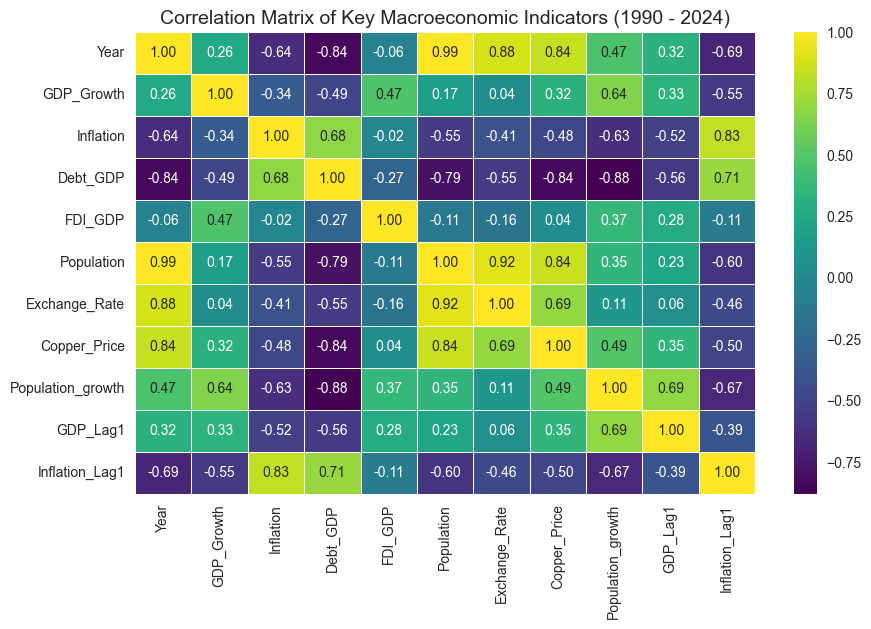

In [44]:
# Correlation heatmap (1990 - 2024)

plt.figure(figsize=(10, 6))
corr_matrix = df_forecast.corr()

sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Key Macroeconomic Indicators (1990 - 2024)", fontsize=14)
plt.show()

### 🧩 Correlation Heatmap Interpretation (1990–2024)

The correlation heatmap provides a high‑level view of how Zambia’s key macroeconomic indicators move together. Several important relationships emerge:

#### **1. Strong Positive Correlations**
- **Population ↔ Year (0.99)**  
  A natural demographic trend — population increases steadily over time.

- **Population Growth ↔ GDP Growth (0.64)**  
  Indicates that demographic expansion is a major long‑term driver of economic output. More workers and consumers contribute to higher GDP.

- **Exchange Rate ↔ Inflation (high positive)**  
  Kwacha depreciation strongly increases inflation due to Zambia’s heavy reliance on imported goods, fuel, and inputs.

#### **2. Moderate Positive Correlations**
- **Copper Price ↔ GDP Growth (0.32)**  
  Copper cycles influence growth, but the relationship is not extremely strong because:
  - GDP responds to *production × price*, not price alone  
  - mining disruptions weaken the link  
  - droughts, inflation, and FX shocks also affect growth  
  - copper effects often appear with lags  

- **Debt-to-GDP ↔ Exchange Rate**  
  Rising debt tends to weaken the currency, especially when external borrowing increases repayment pressure.

#### **3. Negative Correlations**
- **Inflation ↔ GDP Growth**  
  High inflation reduces real incomes, investment, and macroeconomic stability.

- **Debt-to-GDP ↔ GDP Growth**  
  Heavy debt burdens suppress growth by crowding out investment and increasing fiscal stress.

- **Debt-to-GDP ↔ Population Growth (–0.88)**  
  Reflects structural shifts: as population growth slowed slightly in the 2010s, debt surged sharply.

#### **4. Very Weak or No Correlation**
- **Exchange Rate ↔ GDP Growth (0.04)**  
  FX movements do not directly determine GDP growth in a simple year‑to‑year way.  
  Instead, FX affects GDP **indirectly** through inflation, debt servicing costs, and import prices.

- **FDI ↔ Most Variables**  
  FDI flows are project‑specific and not tightly linked to short‑term macroeconomic cycles.

---

### **Overall Insight**
The heatmap reveals a realistic macroeconomic structure for Zambia:

- **Copper drives FX**,  
- **FX drives inflation**,  
- **Inflation and debt drive macro stability**,  
- **Population growth drives long‑term GDP**,  
- **GDP growth is volatile and influenced by multiple shocks**.

This correlation structure helps guide feature selection for forecasting models and highlights the interconnected nature of Zambia’s economy.


# 📊 Exploratory Data Analysis (EDA) Summary

This section summarizes the key insights from Zambia’s macroeconomic indicators between **1990 and 2024**, based on trend analysis, overlays, and the correlation heatmap.

---

## **1. Key Macroeconomic Trends**

### **GDP Growth**
- Highly volatile across the period.
- Strong expansions during copper booms (2004–2011).
- Sharp contractions during droughts, the 2015 FX crisis, and the 2020 COVID‑19 shock.
- Growth is sensitive to external shocks and domestic macro stability.

### **Inflation**
- Extremely high in the early 1990s (hyperinflation).
- Stabilized after 2000 due to reforms and debt relief.
- Spikes reappear during FX crises (2015, 2020).
- Strongly influenced by exchange rate movements and import dependence.

### **Exchange Rate**
- Long-term depreciation of the kwacha.
- Sharp drops during 1998, 2015, and 2020.
- Closely tied to copper price cycles and debt dynamics.

### **Copper Prices**
- Major booms in 2004–2008 and 2010–2011.
- Declines in 2015 and 2020 align with economic slowdowns.
- Copper remains Zambia’s most important export and a key driver of macro stability.

### **Debt-to-GDP**
- Rapid increase after 2012.
- Peaks during the 2020–2022 debt distress period.
- Rising debt amplifies FX pressure and inflation.

### **Population & Population Growth**
- Population rises steadily over time.
- Population growth shows a strong positive relationship with GDP growth, reflecting demographic contributions to output.

---

## **2. Insights from the Correlation Heatmap**

### **Strong Positive Correlations**
- **Population Growth ↔ GDP Growth (0.64)**  
  Demographic expansion is a major long-term driver of output.

- **Exchange Rate ↔ Inflation (high positive)**  
  Kwacha depreciation strongly increases inflation due to import dependence.

- **Year ↔ Population (0.99)**  
  Expected demographic trend.

### **Moderate Positive Correlations**
- **Copper Price ↔ GDP Growth (0.32)**  
  Copper cycles influence growth, but effects are weakened by production disruptions, droughts, and lagged responses.

- **Debt-to-GDP ↔ Exchange Rate**  
  Rising debt tends to weaken the currency.

### **Negative Correlations**
- **Inflation ↔ GDP Growth**  
  High inflation reduces real incomes and investment.

- **Debt-to-GDP ↔ GDP Growth**  
  Heavy debt burdens suppress growth.

- **Debt-to-GDP ↔ Population Growth (–0.88)**  
  Reflects structural shifts: slowing population growth alongside rising debt.

### **Very Weak or No Correlation**
- **Exchange Rate ↔ GDP Growth (0.04)**  
  FX does not directly drive GDP in a simple year‑to‑year way; its effects operate through inflation and debt.

- **FDI ↔ Most Variables**  
  FDI flows are project-specific and not tightly linked to macro cycles.

---

## **3. Overall Economic Interpretation**

The EDA reveals a realistic macroeconomic structure for Zambia:

- **Copper drives FX**,  
- **FX drives inflation**,  
- **Inflation and debt drive macro stability**,  
- **Population growth drives long-term GDP**,  
- **GDP growth is volatile and influenced by multiple shocks**.

These insights guide feature selection and model design for forecasting Zambia’s macroeconomic performance.

---

## **4. Implications for Modeling**

- Include **Copper Price**, **Exchange Rate**, **Inflation**, **Debt-to-GDP**, **Population Growth**, and **lagged GDP** as core predictors.
- Watch for multicollinearity between:
  - Exchange Rate & Inflation  
  - Debt & Exchange Rate  
- Use lagged variables to capture delayed effects.
- Nonlinear models (Random Forest, XGBoost) and multivariate models (VAR) will capture relationships better than simple regressions.

---
